In [1]:
# Colab setup
!pip -q install ehtim
import numpy as np
import ehtim as eh
import ehtim.const_def as ehc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.0/445.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 8.1 MB/s eta 0:00:00
Welcome to eht-imaging! v 1.2.10 



In [10]:
import ehtim.movie as movie

## Source Parameters

In [2]:
ra_hr = 17 + 45/60 + 40.0383/3600
dec_deg = -(29 + 0.60 + 28.069/3600)
rf = 86e9
mjd = 58211

In [3]:
# Image Grid
npix = 256
fov_uas = 160.0
fov = fov_uas * ehc.RADPERUAS

In [4]:
# Static Ring Baseline
total_flux = 2.0
ring_diam_uas = 50
ring_diam_rad = ring_diam_uas * ehc.RADPERUAS

# Define Time

In [5]:
tstart_hr = 0.0
tstop_hr = 10.0/60.0
cadence_s = 2.0

In [6]:
times_hr = np.arange(tstart_hr, tstop_hr + cadence_s/3600.0, cadence_s/3600.0)
print(times_hr)
print("nframes =", len(times_hr))

[0.         0.00055556 0.00111111 0.00166667 0.00222222 0.00277778
 0.00333333 0.00388889 0.00444444 0.005      0.00555556 0.00611111
 0.00666667 0.00722222 0.00777778 0.00833333 0.00888889 0.00944444
 0.01       0.01055556 0.01111111 0.01166667 0.01222222 0.01277778
 0.01333333 0.01388889 0.01444444 0.015      0.01555556 0.01611111
 0.01666667 0.01722222 0.01777778 0.01833333 0.01888889 0.01944444
 0.02       0.02055556 0.02111111 0.02166667 0.02222222 0.02277778
 0.02333333 0.02388889 0.02444444 0.025      0.02555556 0.02611111
 0.02666667 0.02722222 0.02777778 0.02833333 0.02888889 0.02944444
 0.03       0.03055556 0.03111111 0.03166667 0.03222222 0.03277778
 0.03333333 0.03388889 0.03444444 0.035      0.03555556 0.03611111
 0.03666667 0.03722222 0.03777778 0.03833333 0.03888889 0.03944444
 0.04       0.04055556 0.04111111 0.04166667 0.04222222 0.04277778
 0.04333333 0.04388889 0.04444444 0.045      0.04555556 0.04611111
 0.04666667 0.04722222 0.04777778 0.04833333 0.04888889 0.0494

# Generate Frames

In [7]:
# Hotspot Parameters
hotspot_flux = 0.3 # Jy
hotspot_fwhm_uas = 6.0 # uas
hotspot_fwhm_rad = hotspot_fwhm_uas * ehc.RADPERUAS

In [8]:
# Hotspot Orbital Period
period_min = 4.0
omega = 2*np.pi / (period_min/60.0)

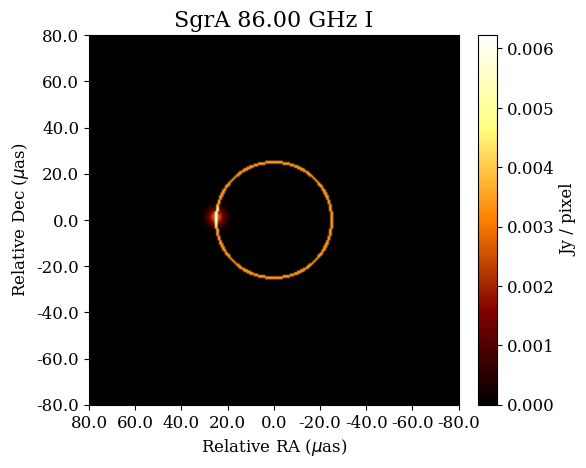

In [15]:
imlist = []

for t_hr in times_hr:
  phi = omega * t_hr

  r_ring = ring_diam_rad / 2.0
  x_hot = r_ring * np.cos(phi)
  y_hot = r_ring * np.sin(phi)

  # Build analytic model for this frame
  mod = eh.model.Model(ra_hr, dec_deg, rf = rf, source = "SgrA", mjd = mjd)

  # Ring gets remaining flux
  mod = mod.add_ring(F0 = total_flux - hotspot_flux, d = ring_diam_rad, x0 = 0.0, y0 = 0.0)

  # Add Hotspot
  mod = mod.add_circ_gauss(F0 = hotspot_flux, FWHM = hotspot_fwhm_rad, x0 = x_hot, y0 = y_hot)

  # Rasterize to image
  im = mod.make_image(fov, npix)

  im.time = float(t_hr)

  imlist.append(im)

imlist[1].display()

In [11]:
mov = movie.merge_im_list(imlist, interp = "linear", bounds_error = False)

mov.export_mp4(
    out = "toy.mp4",
    fps = 20,
    dpi = 160,
    scale = "lin",
    dynamic_range = 1000.0,
    cfun = "afmhot",
    label_time = True,
    verbose = True
)


Merging 301 frames from MJD 58211 0.00 hr to MJD 58211 0.17 hr
processing frame 0 of 301
processing frame 0 of 301
processing frame 1 of 301
processing frame 2 of 301
processing frame 3 of 301
processing frame 4 of 301
processing frame 5 of 301
processing frame 6 of 301
processing frame 7 of 301
processing frame 8 of 301
processing frame 9 of 301
processing frame 10 of 301
processing frame 11 of 301
processing frame 12 of 301
processing frame 13 of 301
processing frame 14 of 301
processing frame 15 of 301
processing frame 16 of 301
processing frame 17 of 301
processing frame 18 of 301
processing frame 19 of 301
processing frame 20 of 301
processing frame 21 of 301
processing frame 22 of 301
processing frame 23 of 301
processing frame 24 of 301
processing frame 25 of 301
processing frame 26 of 301
processing frame 27 of 301
processing frame 28 of 301
processing frame 29 of 301
processing frame 30 of 301
processing frame 31 of 301
processing frame 32 of 301
processing frame 33 of 301
pr